
# Severstal: Steel Defect Detection — Exploratory Data Analysis & Validation Strategy

Welcome to the comprehensive data analysis and validation pipeline for the **Severstal: Steel Defect Detection** Kaggle competition. In this notebook, we set up a robust foundation for building high-performance computer vision segmentation models.

In [ ]:
pip install iterative-stratification -q

In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from iterstrat.ml_stratifiers import MultilabelStratifiedKFold
import cv2
import os
from PIL import Image
import random

## 1. Environment Setup & Data Acquisition

We begin by installing required dependencies and securely fetching the competition dataset directly from Kaggle using `kagglehub`.

In [ ]:
import os

os.environ["KAGGLE_KEY"] = "66235ac7057c609edc6803926b672559"
os.environ["KAGGLE_USERNAME"] = "narekgabrielyan"

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.competition_download('severstal-steel-defect-detection')

print("Path to competition files:", path)

Path to competition files: /root/.cache/kagglehub/competitions/severstal-steel-defect-detection


In [ ]:
!ls /root/.cache/kagglehub/competitions/severstal-steel-defect-detection

sample_submission.csv  test_images  train.csv  train_images


In [ ]:
labels_df = pd.read_csv('/root/.cache/kagglehub/competitions/severstal-steel-defect-detection/train.csv')

In [ ]:
labels_df

,ImageId,ClassId,EncodedPixels
0,0002cc93b.jpg,1,29102 12 29346 24 29602 24 29858 24 30114 24 3...
1,0007a71bf.jpg,3,18661 28 18863 82 19091 110 19347 110 19603 11...
2,000a4bcdd.jpg,1,37607 3 37858 8 38108 14 38359 20 38610 25 388...
3,000f6bf48.jpg,4,131973 1 132228 4 132483 6 132738 8 132993 11 ...
4,0014fce06.jpg,3,229501 11 229741 33 229981 55 230221 77 230468...
...,...,...,...
7090,ffcf72ecf.jpg,3,121911 34 122167 101 122422 169 122678 203 122...
7091,fff02e9c5.jpg,3,207523 3 207777 9 208030 15 208283 22 208537 2...
7092,fffe98443.jpg,3,105929 5 106177 14 106424 24 106672 33 106923 ...
7093,ffff4eaa8.jpg,3,16899 7 17155 20 17411 34 17667 47 17923 60 18...


In [ ]:
# 1. Path to train_images folder (where all ~12,568 images are located)
data_dir = '/root/.cache/kagglehub/competitions/severstal-steel-defect-detection'
train_img_dir = os.path.join(data_dir, 'train_images')

# Get all image file names
all_images = sorted([f for f in os.listdir(train_img_dir) if f.endswith('.jpg')])
df_folds = pd.DataFrame({'ImageId': all_images})

# 2. Create 4 binary classes (0 or 1)
# The labels dataframe
for c in range(1, 5):
    defect_imgs = set(labels_df[(labels_df['ClassId'] == c) & (labels_df['EncodedPixels'].notna())]['ImageId'])
    df_folds[f'class_{c}'] = df_folds['ImageId'].apply(lambda x: 1 if x in defect_imgs else 0)

# Add a helper column for total defects count
df_folds['defects_count'] = df_folds[['class_1', 'class_2', 'class_3', 'class_4']].sum(axis=1)

# 3. 5-Fold Multilabel Stratified Split (seed=42)
mskf = MultilabelStratifiedKFold(n_splits=5, shuffle=True, random_state=42)
df_folds['fold'] = -1

X = df_folds['ImageId'].values
y = df_folds[['class_1', 'class_2', 'class_3', 'class_4']].values

for fold_idx, (train_idx, val_idx) in enumerate(mskf.split(X, y)):
    df_folds.loc[val_idx, 'fold'] = fold_idx

# 4. Save train_folds.csv
df_folds.to_csv('train_folds.csv', index=False)
print("✅ train_folds.csv successfully created and saved:\n")

# 5. Check distribution across folds
print("--- CLASS DISTRIBUTION PER FOLD ---")
summary = []
for f in range(5):
    sub = df_folds[df_folds['fold'] == f]
    summary.append({
        'Fold': f,
        'Total': len(sub),
        'Class 1': sub['class_1'].sum(),
        'Class 2': sub['class_2'].sum(),
        'Class 3': sub['class_3'].sum(),
        'Class 4': sub['class_4'].sum(),
        'No Defect': (sub['defects_count'] == 0).sum()
    })

print(pd.DataFrame(summary).to_string(index=False))

✅ train_folds.csv successfully created and saved:

--- CLASS DISTRIBUTION PER FOLD ---
 Fold  Total  Class 1  Class 2  Class 3  Class 4  No Defect
    0   2514      179       49     1030      161       1184
    1   2514      180       49     1030      160       1178
    2   2514      180       50     1030      160       1184
    3   2513      179       49     1030      160       1170
    4   2513      179       50     1030      160       1186


3. Exploratory Data Analysis (EDA)

Understanding class distribution and co-occurrence patterns is critical for addressing class imbalance in industrial surface inspection tasks.

In [ ]:
df = pd.read_csv("/content/train_folds.csv")
df

,ImageId,class_1,class_2,class_3,class_4,defects_count,fold
0,0002cc93b.jpg,1,0,0,0,1,3
1,00031f466.jpg,0,0,0,0,0,4
2,000418bfc.jpg,0,0,0,0,0,3
3,000789191.jpg,0,0,0,0,0,1
4,0007a71bf.jpg,0,0,1,0,1,2
...,...,...,...,...,...,...,...
12563,fff0295e1.jpg,0,0,0,0,0,4
12564,fff02e9c5.jpg,0,0,1,0,1,1
12565,fffe98443.jpg,0,0,1,0,1,4
12566,ffff4eaa8.jpg,0,0,1,0,1,4


<Axes: xlabel='defects_count', ylabel='count'>

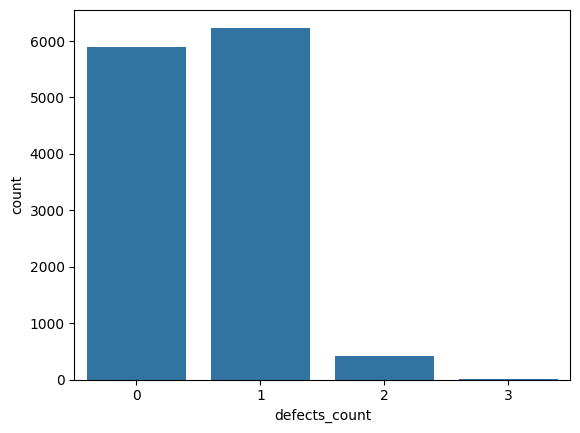

In [ ]:
sns.countplot(data = df,x = 'defects_count')

In [ ]:
class1_count = df['class_1'].sum()
class2_count = df['class_2'].sum()
class3_count = df['class_3'].sum()
class4_count = df['class_4'].sum()
classes = [class1_count,class2_count,class3_count,class4_count]

<Axes: >

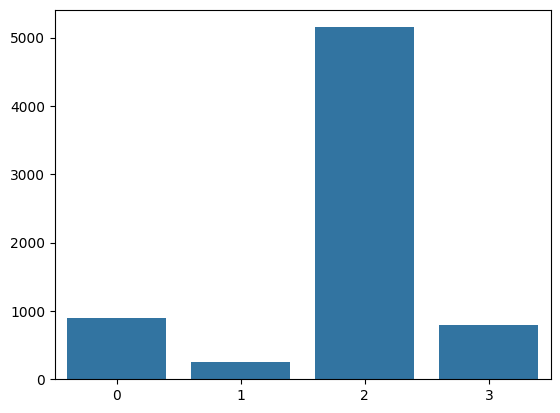

In [ ]:
sns.barplot(data = classes)

In [ ]:
classes

[np.int64(897), np.int64(247), np.int64(5150), np.int64(801)]

## 4. Advanced Validation Strategy: Multilabel Stratified K-Fold

To ensure reliable model evaluation and prevent data leakage, standard K-Fold cross-validation is insufficient here due to severe multi-label imbalance. We employ **Multilabel Stratified K-Fold (`iterstrat`)** to maintain proportional class representations across all folds.

In this pipeline, we assign **Fold 0 as the validation set** and the remaining folds as the training set, ensuring an identical and balanced distribution of all defect classes across both subsets.

In [ ]:
train_df = df[df['fold'] != 0]
val_df = df[df['fold'] == 0]

In [ ]:
train_df.head(5)

,ImageId,class_1,class_2,class_3,class_4,defects_count,fold
0,0002cc93b.jpg,1,0,0,0,1,3
1,00031f466.jpg,0,0,0,0,0,4
2,000418bfc.jpg,0,0,0,0,0,3
3,000789191.jpg,0,0,0,0,0,1
4,0007a71bf.jpg,0,0,1,0,1,2


In [ ]:
val_df.head(5)

,ImageId,class_1,class_2,class_3,class_4,defects_count,fold
7,0014fce06.jpg,0,0,1,0,1,0
8,001982b08.jpg,0,0,0,0,0,0
11,0025bde0c.jpg,0,0,1,1,2,0
13,002e73b3c.jpg,0,0,0,0,0,0
17,0046839bd.jpg,0,0,1,0,1,0


In [ ]:
class1_count_t = train_df['class_1'].sum()
class2_count_t = train_df['class_2'].sum()
class3_count_t = train_df['class_3'].sum()
class4_count_t = train_df['class_4'].sum()
classes_t = [class1_count_t,class2_count_t,class3_count_t,class4_count_t]

In [ ]:
classes_t

[np.int64(718), np.int64(198), np.int64(4120), np.int64(640)]

In [ ]:
class1_count_v = val_df['class_1'].sum()
class2_count_v = val_df['class_2'].sum()
class3_count_v = val_df['class_3'].sum()
class4_count_v = val_df['class_4'].sum()
classes_v = [class1_count_v,class2_count_v,class3_count_v,class4_count_v]

In [ ]:
classes_v

[np.int64(179), np.int64(49), np.int64(1030), np.int64(161)]

<Axes: >

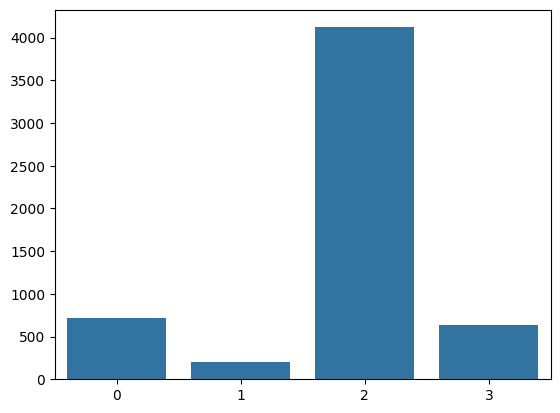

In [ ]:
sns.barplot(data = classes_t)

<Axes: xlabel='defects_count', ylabel='count'>

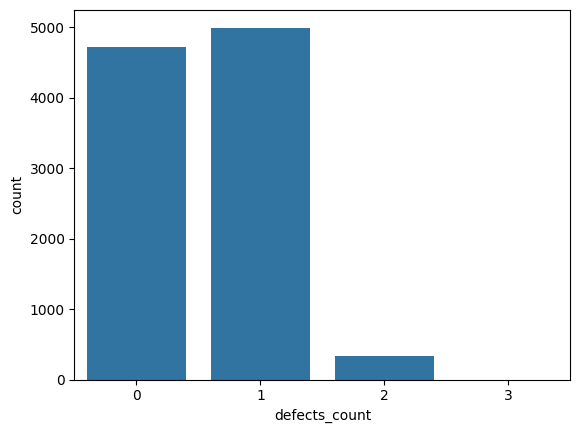

In [ ]:
sns.countplot(data = train_df,x = 'defects_count')

<Axes: >

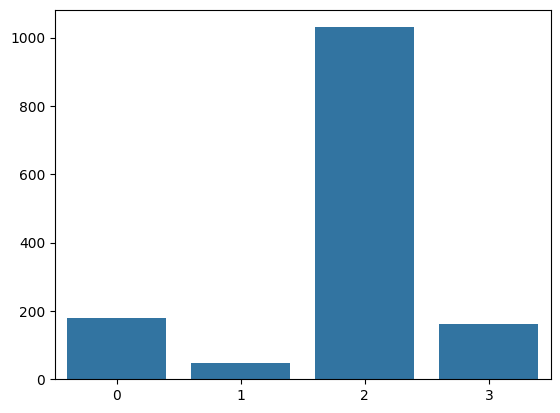

In [ ]:
sns.barplot(data = classes_v)

<Axes: xlabel='defects_count', ylabel='count'>

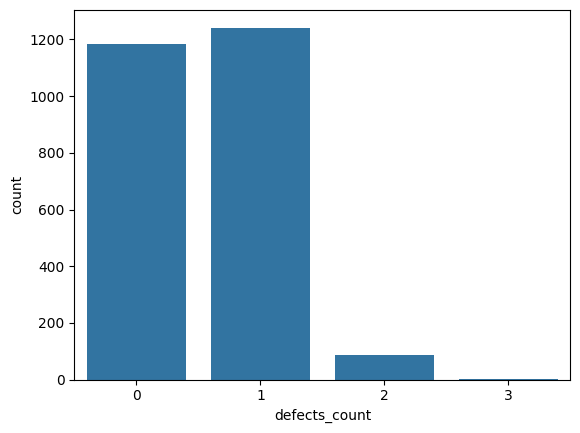

In [ ]:
sns.countplot(data = val_df,x = 'defects_count')

## 5. Defect Class Color-Coding & Visualization

To keep visual inspections clear and intuitive during mask debugging, each of the four defect classes is assigned a distinct, high-contrast visual color:

* 🔴 **Class 1 — Red:** Primary structural anomaly marker
* 🟢 **Class 2 — Green:** Secondary surface defect indicator
* 🔵 **Class 3 — Blue:** Micro-fracture and pattern identifier
* 🟡 **Class 4 — Yellow:** Complex defect boundary marker


In [ ]:
def rle_decode(mask_rle, shape=(256, 1600)):
    if pd.isna(mask_rle) or mask_rle == '':
        return np.zeros(shape, dtype=np.uint8)

    s = mask_rle.split()
    starts = np.asarray(s[0::2], dtype=int) - 1
    lengths = np.asarray(s[1::2], dtype=int)
    ends = starts + lengths

    img = np.zeros(shape[0] * shape[1], dtype=np.uint8)
    for lo, hi in zip(starts, ends):
        img[lo:hi] = 1

    return img.reshape(shape, order='F')


In [ ]:
def id_to_masks(imageid):
  img_name = df.loc[imageid]['ImageId']
  img_path = os.path.join(train_img_dir, img_name)
  image_pil = Image.open(img_path).convert("RGB")

  encodeds = labels_df[labels_df['ImageId'] == img_name]['EncodedPixels'].to_list()
  classes = labels_df[labels_df['ImageId'] == img_name]['ClassId'].to_list()
  masks = []
  for i in encodeds:
    masks.append(rle_decode(i))

  return image_pil,masks,classes

In [ ]:
def vizualizing_mask(image_pil, masks, colourids):
    plt.figure(figsize=(10, 10))
    plt.imshow(image_pil)

    colors = {
        1: [1, 0, 0, 0.4],  # class 1 -> red
        2: [0, 1, 0, 0.4],  # class 2 -> green
        3: [0, 0, 1, 0.4],  # class 3 -> blue
        4: [1, 1, 0, 0.4],  # class 4 -> yellow
    }

    for mask, class_id in zip(masks, colourids):
        color = colors[class_id]

        colored_mask = np.zeros((*mask.shape, 4))
        colored_mask[mask == 1] = color

        plt.imshow(colored_mask)

    plt.axis("off")
    plt.show()

In [ ]:
indexes1 = df[df['class_1'] == 1].index.tolist()
indexes2 = df[df['class_2'] == 1].index.tolist()
indexes3 = df[df['class_3'] == 1].index.tolist()
indexes4 = df[df['class_4'] == 1].index.tolist()

random_indices = random.sample(indexes1, 3)+random.sample(indexes2, 3)+random.sample(indexes3, 3)+random.sample(indexes4, 3)

In [ ]:
random_indices

[7331, 11155, 1441, 11616, 280, 7745, 5988, 5051, 384, 81, 12099, 967]

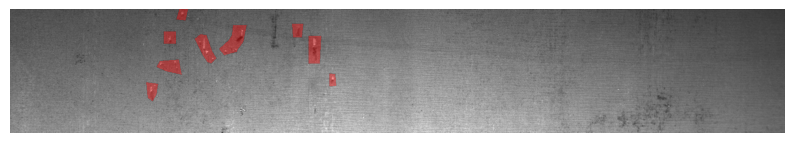

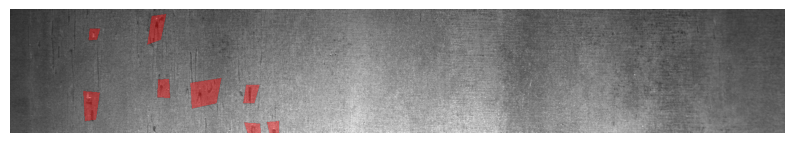

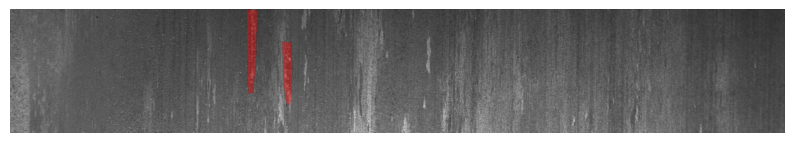

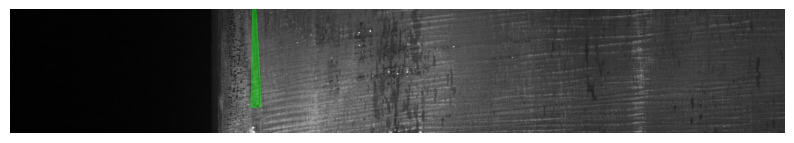

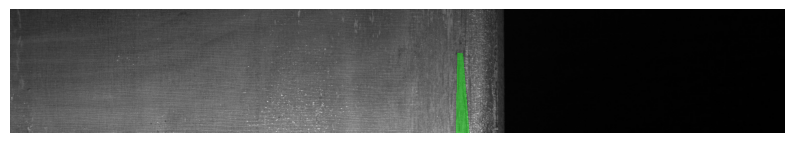

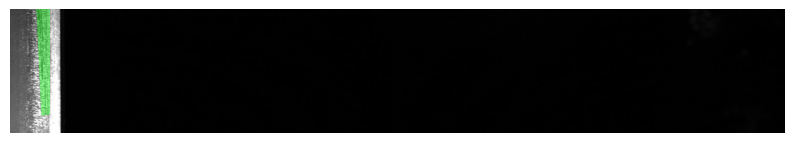

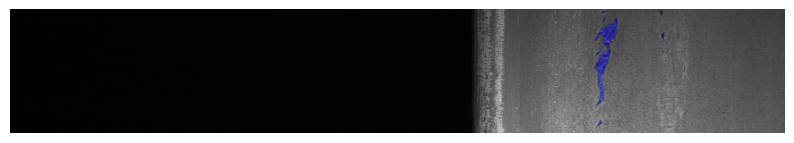

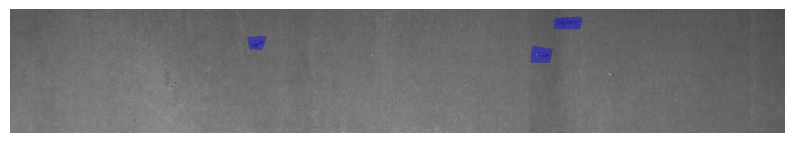

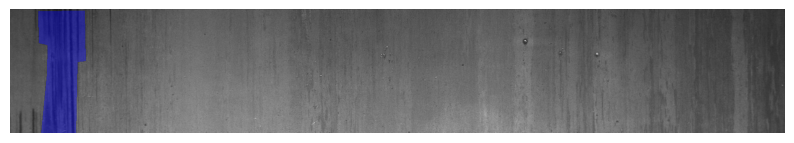

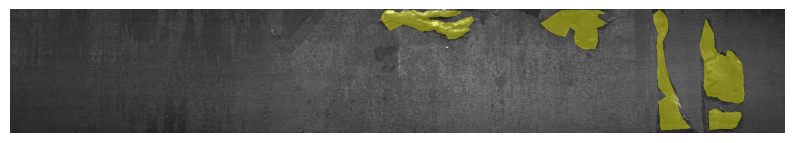

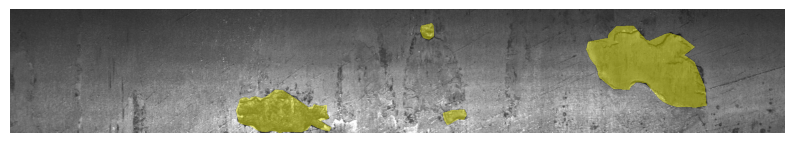

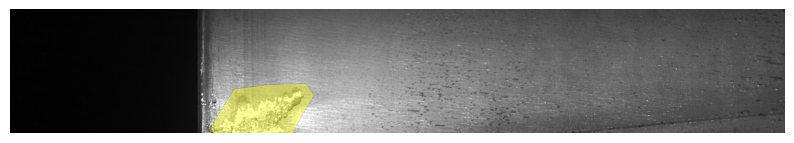

In [ ]:
for idx in random_indices:
    img_data = id_to_masks(idx)
    image_pil = img_data[0]
    true_masks = img_data[1]
    true_classes = img_data[2]
    vizualizing_mask(image_pil, true_masks, true_classes)
